# Projeto Integrador IV — Ciência de Dados aplicado a Situações de Mercado
### Etapa 1 — Análise Exploratória e Visualização de Dados

**Curso:** Banco de Dados — SENAC EAD
**Disciplina:** Mineração de Dados

**Integrantes do grupo:**
- ARNO WENDT FILHO
- DAVID CALAZANS TAVARES
- RAFAELLA SILVA
- RHAYANE BERNARDINO SOUZA LEAO




## 1. Fonte de dados escolhida

**Fonte:** *Brazilian E-Commerce Public Dataset by Olist* — Kaggle
Link: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

**O que é:** mais de 100 mil pedidos reais e anonimizados feitos entre 2016 e 2018 na **Olist
Store**, um marketplace brasileiro que conecta pequenos e médios vendedores a grandes
marketplaces (Mercado Livre, Americanas, etc.). O conjunto é dividido em várias tabelas
relacionadas: pedidos, itens do pedido, clientes, vendedores, produtos, pagamentos e avaliações.

**Por que essa fonte se encaixa em "situação de mercado":** é um cenário real de e-commerce
brasileiro em que a gestão precisa decidir, por exemplo, em quais categorias de produto investir,
para quais estados focar logística e marketing, como está o prazo de entrega (fator crítico de
satisfação) e quais formas de pagamento priorizar no checkout — decisões de negócio apoiadas por
dados.

## 2. Escopo da exploração

- **Recorte:** pedidos com status `delivered` (efetivamente entregues — o que representa vendas
  concretizadas), usando as tabelas `orders`, `order_items`, `customers`, `products` e
  `order_payments`.
- **O que será analisado:** evolução das vendas ao longo do tempo, categorias de produto mais
  relevantes, distribuição geográfica das vendas por estado, prazo de entrega e formas de
  pagamento utilizadas.
- **Fora do escopo desta etapa:** análise de avaliações/reviews (tabela `order_reviews`),
  geolocalização detalhada (lat/long) e qualquer modelo preditivo — reservados para etapas
  futuras, se solicitado.
- **Perguntas de negócio que guiam a análise:**
  1. As vendas têm sazonalidade ao longo do tempo?
  2. Quais categorias de produto geram mais receita?
  3. Em quais estados brasileiros a Olist mais vende?
  4. Como está o prazo de entrega aos clientes?
  5. Quais formas de pagamento os clientes mais utilizam?



## 3. Ambiente e bibliotecas

Notebook pensado para o **Google Colab**, usando **Pandas**, **NumPy** e **Matplotlib**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)


## 4. Baixando os dados (Kaggle)

O dataset está hospedado no Kaggle. Para baixar direto no Colab, é preciso de um **token de API
do Kaggle** (gratuito). Passo a passo:

1. Crie uma conta gratuita em [kaggle.com](https://www.kaggle.com) (se ainda não tiver).
2. Acesse **kaggle.com/settings** → seção **API** → botão **"Create New Token"**.
   Isso baixa um arquivo `kaggle.json` no seu computador.
3. Rode a célula abaixo e, quando o botão de upload aparecer, selecione o `kaggle.json` baixado.


In [2]:
from google.colab import files
uploaded = files.upload()  # selecione o arquivo kaggle.json baixado do Kaggle


Saving kaggle.json to kaggle.json


In [3]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -o -q brazilian-ecommerce.zip -d olist_data
!ls olist_data


Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 139MB/s]

olist_customers_dataset.csv	  olist_orders_dataset.csv
olist_geolocation_dataset.csv	  olist_products_dataset.csv
olist_order_items_dataset.csv	  olist_sellers_dataset.csv
olist_order_payments_dataset.csv  product_category_name_translation.csv
olist_order_reviews_dataset.csv


In [4]:
caminho = 'olist_data/'

orders = pd.read_csv(caminho + 'olist_orders_dataset.csv',
                      parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date',
                                   'order_estimated_delivery_date'])
customers = pd.read_csv(caminho + 'olist_customers_dataset.csv')
order_items = pd.read_csv(caminho + 'olist_order_items_dataset.csv')
products = pd.read_csv(caminho + 'olist_products_dataset.csv')
payments = pd.read_csv(caminho + 'olist_order_payments_dataset.csv')

print('orders:', orders.shape)
print('customers:', customers.shape)
print('order_items:', order_items.shape)
print('products:', products.shape)
print('payments:', payments.shape)


orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)


## 5. Análise exploratória com Pandas / NumPy

O dataset é relacional (várias tabelas), então a primeira etapa da análise exploratória é juntar
(`merge`) as tabelas necessárias, além de limpar e derivar colunas de interesse.


In [5]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 6.1+ MB


In [6]:
orders['order_status'].value_counts()


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [7]:
# Mantemos apenas pedidos efetivamente entregues: representam vendas concretizadas
pedidos_entregues = orders[orders['order_status'] == 'delivered'].copy()
print(f"Pedidos entregues: {len(pedidos_entregues):,} de {len(orders):,} totais")


Pedidos entregues: 96,478 de 99,441 totais


In [8]:
# Junta itens do pedido + produto + pedido (só entregues) + cliente
itens = order_items.merge(products, on='product_id', how='left')

itens = itens.merge(
    pedidos_entregues[['order_id', 'customer_id', 'order_purchase_timestamp',
                        'order_delivered_customer_date', 'order_estimated_delivery_date']],
    on='order_id', how='inner'
)

itens = itens.merge(customers, on='customer_id', how='left')

print(itens.shape)
itens.head()


(110197, 23)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [9]:
# Colunas derivadas
itens['Receita'] = itens['price'] + itens['freight_value']
itens['AnoMes'] = itens['order_purchase_timestamp'].dt.to_period('M').astype(str)
itens['PrazoEntregaDias'] = (itens['order_delivered_customer_date'] - itens['order_purchase_timestamp']).dt.days

# Exemplo de uso do NumPy: sinaliza pedidos entregues fora do prazo estimado
itens['AtrasoEntrega'] = np.where(
    itens['order_delivered_customer_date'] > itens['order_estimated_delivery_date'],
    'Atrasado', 'No prazo'
)

itens[['Receita', 'AnoMes', 'PrazoEntregaDias', 'AtrasoEntrega']].describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Receita,110197.0,NaN,NaN,NaN,139.929161,189.319151,6.08,55.18,92.13,157.51,6929.31
AnoMes,110197,23,2017-11,8475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PrazoEntregaDias,110189.0,NaN,NaN,NaN,12.007342,9.451153,0.0,6.0,10.0,15.0,209.0
AtrasoEntrega,110197,2,No prazo,101483,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# % de pedidos entregues com atraso (métrica de qualidade logística)
(itens['AtrasoEntrega'].value_counts(normalize=True) * 100).round(1)


,proportion
AtrasoEntrega,
No prazo,92.1
Atrasado,7.9


## 6. Visualizações (Matplotlib)

Cinco visualizações a partir da fonte escolhida, cada uma com a justificativa de como apoia a
tomada de decisão.


### 6.1 Receita total por mês (sazonalidade)

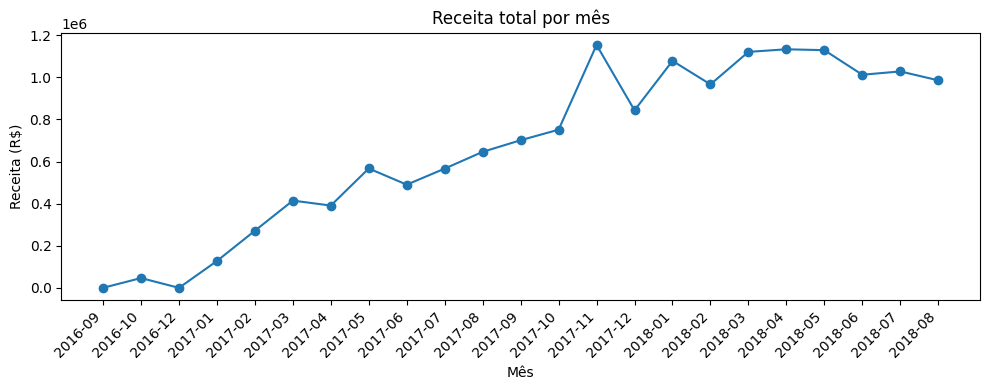

In [11]:
receita_mes = itens.groupby('AnoMes')['Receita'].sum().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(receita_mes.index, receita_mes.values, marker='o')
ax.set_title('Receita total por mês')
ax.set_xlabel('Mês'); ax.set_ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Como ajuda na tomada de decisão:** revela picos e quedas de vendas ao longo do tempo (ex.:
datas comemorativas). Apoia o **planejamento de estoque** dos vendedores parceiros e o
**calendário de campanhas de marketing** da plataforma.

### 6.2 Top 10 categorias de produto por receita

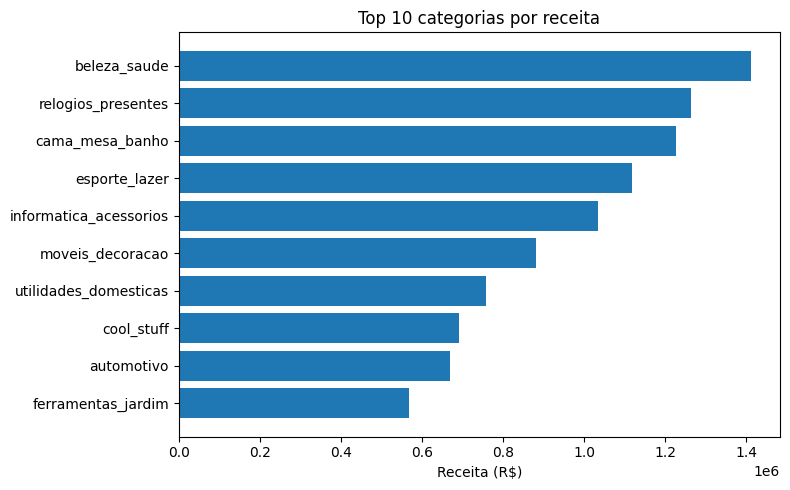

In [12]:
receita_cat = itens.groupby('product_category_name')['Receita'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(receita_cat.index[::-1], receita_cat.values[::-1])
ax.set_title('Top 10 categorias por receita')
ax.set_xlabel('Receita (R$)')
plt.tight_layout()
plt.show()


**Como ajuda na tomada de decisão:** aponta as **categorias mais lucrativas** da plataforma.
Apoia decisões de **recrutamento de novos vendedores** nessas categorias e de **destaque delas em
promoções e na página inicial**.

### 6.3 Top 10 estados por receita

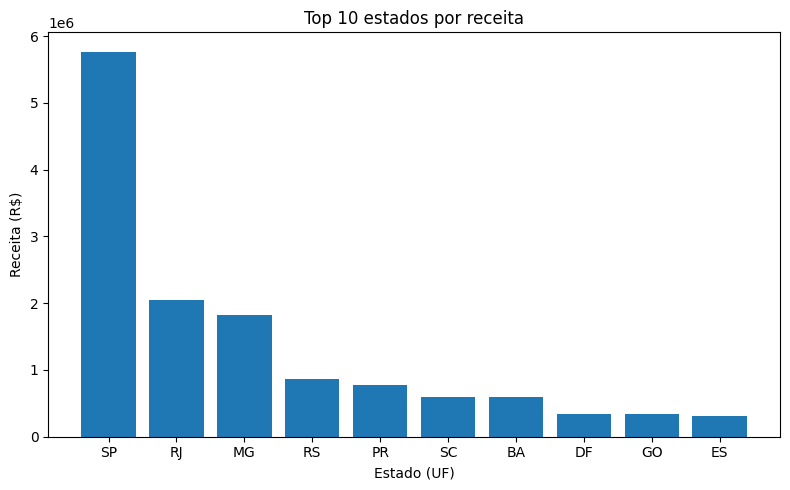

In [13]:
receita_estado = itens.groupby('customer_state')['Receita'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(receita_estado.index, receita_estado.values)
ax.set_title('Top 10 estados por receita')
ax.set_xlabel('Estado (UF)'); ax.set_ylabel('Receita (R$)')
plt.tight_layout()
plt.show()


**Como ajuda na tomada de decisão:** mostra a **concentração geográfica das vendas** no Brasil.
Apoia decisões de **expansão de centros de distribuição** e de **campanhas regionais de
marketing** focadas nos estados de maior potencial.

### 6.4 Distribuição do prazo de entrega

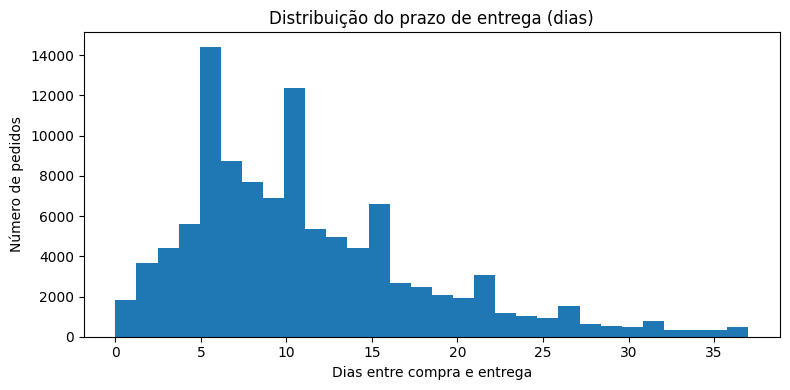

Prazo médio de entrega (dias): 11.2


In [14]:
prazo_valido = itens['PrazoEntregaDias'].dropna()
prazo_valido = prazo_valido[prazo_valido < prazo_valido.quantile(0.98)]  # remove outliers extremos

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prazo_valido, bins=30)
ax.set_title('Distribuição do prazo de entrega (dias)')
ax.set_xlabel('Dias entre compra e entrega'); ax.set_ylabel('Número de pedidos')
plt.tight_layout()
plt.show()

print('Prazo médio de entrega (dias):', round(prazo_valido.mean(), 1))


**Como ajuda na tomada de decisão:** a entrega é um dos principais fatores de satisfação em
e-commerce. Esse gráfico apoia decisões de **negociação com transportadoras**, **escolha de
centros de distribuição mais próximos dos clientes** e ajuda a definir **prazos estimados mais
realistas** para o cliente no momento da compra.

### 6.5 Formas de pagamento utilizadas

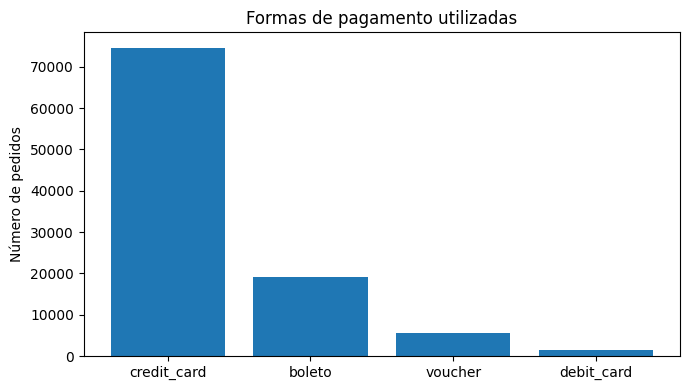

In [15]:
pedidos_pagamento = payments.merge(pedidos_entregues[['order_id']], on='order_id', how='inner')
contagem_pag = pedidos_pagamento['payment_type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(contagem_pag.index, contagem_pag.values)
ax.set_title('Formas de pagamento utilizadas')
ax.set_ylabel('Número de pedidos')
plt.tight_layout()
plt.show()


**Como ajuda na tomada de decisão:** mostra a **preferência de pagamento** dos clientes
brasileiros (ex.: cartão de crédito x boleto). Apoia decisões sobre **quais meios de pagamento
priorizar no checkout**, negociação de taxas com adquirentes e estratégias de **parcelamento**.

## 7. Conclusão

A análise exploratória dos dados da Olist mostrou que as vendas do marketplace não são uniformes ao longo do tempo, nem entre categorias, regiões, prazos de entrega ou formas de pagamento. É justamente nessas diferenças que estão as oportunidades de decisão para o negócio. O gráfico de receita por mês revelou períodos de maior e menor movimento, o que orienta quando reforçar estoque e campanhas. As categorias e os estados com maior receita mostram onde a empresa já é forte e onde vale concentrar esforço de vendedores e logística. A distribuição do prazo de entrega expõe um ponto sensível da operação, já que entrega é um dos principais fatores de satisfação em e-commerce, sugerindo espaço para negociar com transportadoras ou revisar prazos estimados. Por fim, o predomínio de determinadas formas de pagamento indica onde a plataforma deve priorizar investimento em checkout e parcelamento.

Juntas, essas cinco visualizações formam uma base simples, mas concreta, de apoio à tomada de decisão: um gestor da Olist (ou de um vendedor parceiro) conseguiria usar esses gráficos para decidir onde investir em estoque, marketing, logística e meios de pagamento, sem precisar recorrer a modelos mais complexos nesta etapa.

Como limitação, vale destacar que o dataset cobre apenas o período de 2016 a 2018 e não inclui dados de avaliações (reviews) nem geolocalização detalhada, análises que poderiam aprofundar ainda mais a compreensão do comportamento do cliente em etapas futuras do projeto.
